# **Sales Analysis**

In [57]:
import pandas as pd
import numpy
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [58]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

In [59]:
eda_df = pd.read_csv(
    'dataset/processed/ecommerce_processed.csv',
    parse_dates=['order_date']
)

In [60]:
eda_df.sample(10)

,order_date,order_year,order_month,order_day_of_week,part_day,is_weekend,customer_name,gender,age,age_group,customer_segment,country,order_status,category,sub_category,unit_price_usd,price_tier,quantity,quantity_segment,gross_revenue_usd,discount_amount_usd,discount_percent,discount_tier,is_discounted,revenue_usd,order_value_segment,profit_usd,profit_margin_percent,payment_method,shipping_method,shipping_cost_usd,shipping_cost_percent,delivery_days,delivery_speed,shipping_country,shipment_type,rating,customer_loyalty_score,loyalty_tier,coupon_used,session_duration_min,engagement_level,pages_visited,abandoned_cart_before,fraud_risk_score,fraud_risk_level,device_type,campaign_source,traffic_source
538003,2025-09-11 12:33:38.190981,2025,9,Thu,Afternoon,No,Timothy Wright,Male,70,65+,Regular,Italy,Returned,Electronics,Audio,239.18,Luxury,2,Small Basket,478.36,23.92,5,Low Discount,Yes,454.44,High,160.42,35.30,Bank Transfer,Economy,15.49,3.41,1,Fast,Italy,Domestic,4,64.60,Medium,Yes,1.30,Low,7,No,50.90,Medium,Desktop,Instagram,Email
522094,2024-07-16 17:56:18.564390,2024,7,Tue,Afternoon,No,Brett Meyer,Male,57,55-64,Premium,Canada,Completed,Clothing,Shoes,42.95,Budget,5,Bulk,214.75,21.48,10,Low Discount,Yes,193.27,Medium,81.67,42.26,Credit Card,Economy,13.94,7.21,14,Slow,Canada,Domestic,2,57.00,Medium,Yes,30.90,Medium,3,No,10.90,Low,Tablet,Affiliate,Search
199814,2024-03-02 04:05:45.682348,2024,3,Sat,Night,Yes,Diana Frazier,Female,48,45-54,Regular,Netherlands,Completed,Health,Supplements,147.14,Premium,5,Bulk,735.70,73.57,10,Low Discount,Yes,662.13,Very High,259.53,39.20,Apple Pay,Next Day,5.57,0.84,12,Slow,Netherlands,Domestic,2,81.40,High,Yes,30.50,Medium,16,Yes,69.40,Medium,Tablet,Organic,Direct
510010,2025-04-14 00:46:28.917947,2025,4,Mon,Night,No,Priscilla Peck,Female,41,35-44,VIP,France,Completed,Sports,Sports Wear,160.23,Premium,4,Bulk,640.92,64.09,10,Low Discount,Yes,576.83,High,202.63,35.13,PayPal,Economy,15.46,2.68,12,Slow,France,Domestic,3,34.50,Medium,No,35.90,Medium,15,No,96.40,High,Desktop,Google Ads,Referral
388664,2024-07-28 03:31:22.783044,2024,7,Sun,Night,Yes,Samantha Smith,Female,44,35-44,Regular,Netherlands,Completed,Home,Appliances,41.82,Budget,3,Small Basket,125.46,6.27,5,Low Discount,Yes,119.19,Medium,57.30,48.07,Bank Transfer,Standard,7.51,6.30,14,Slow,Netherlands,Domestic,1,66.60,Medium,Yes,12.60,Low,12,No,98.10,High,Tablet,Google Ads,Search
683618,2024-03-17 09:12:19.245002,2024,3,Sun,Morning,Yes,Chad Pham,Male,51,45-54,Premium,United States,Pending,Sports,Sports Wear,51.82,Mid-Range,3,Small Basket,155.46,7.77,5,Low Discount,Yes,147.69,Medium,64.05,43.37,Debit Card,Standard,9.41,6.37,1,Fast,United States,Domestic,2,3.80,Low,Yes,52.30,High,6,Yes,7.10,Low,Desktop,Instagram,Direct
404505,2025-07-08 22:38:20.421405,2025,7,Tue,Evening,No,Stephen Santana,Male,26,25-34,Regular,United Kingdom,Pending,Health,Fitness,153.58,Premium,4,Bulk,614.32,92.15,15,Medium Discount,Yes,522.17,High,264.13,50.58,Debit Card,Express,8.70,1.67,10,Slow,United Kingdom,Domestic,2,7.40,Low,No,34.70,Medium,18,Yes,0.10,Low,Mobile,Affiliate,Email
23413,2025-07-07 13:42:31.346644,2025,7,Mon,Afternoon,No,Taylor Lewis,Female,68,65+,Regular,United States,Completed,Health,Medical Devices,28.95,Budget,4,Bulk,115.80,28.95,25,High Discount,Yes,86.85,Low,19.17,22.07,PayPal,Next Day,18.63,21.45,7,Standard,United States,Domestic,3,24.80,Low,No,12.10,Low,3,No,2.80,Low,Mobile,Facebook,Social
763807,2024-04-22 04:53:14.361167,2024,4,Mon,Night,No,Alexis Willis,Male,29,25-34,Regular,Canada,Returned,Electronics,Smartphones,17.12,Budget,5,Bulk,85.60,8.56,10,Low Discount,Yes,77.04,Low,22.54,29.26,Credit Card,Economy,23.80,30.89,7,Standard,Canada,Domestic,1,20.60,Low,Yes,50.90,High,5,No,60.60,Medium,Mobile,Facebook,Direct
202666,2024-03-31 19:58:53.736920,2024,3,Sun,Evening,Yes,Timothy Washington,Male,42,35-44,Regular,Italy,Completed,Electronics,Tablets,374.08,Luxury,4,Bulk,"1,496.32",0.00,0,No Discount,No,"1,496.32",Very High,761.48,50.89,Credit Card,Economy,16

## 1.1 Revenue by Time

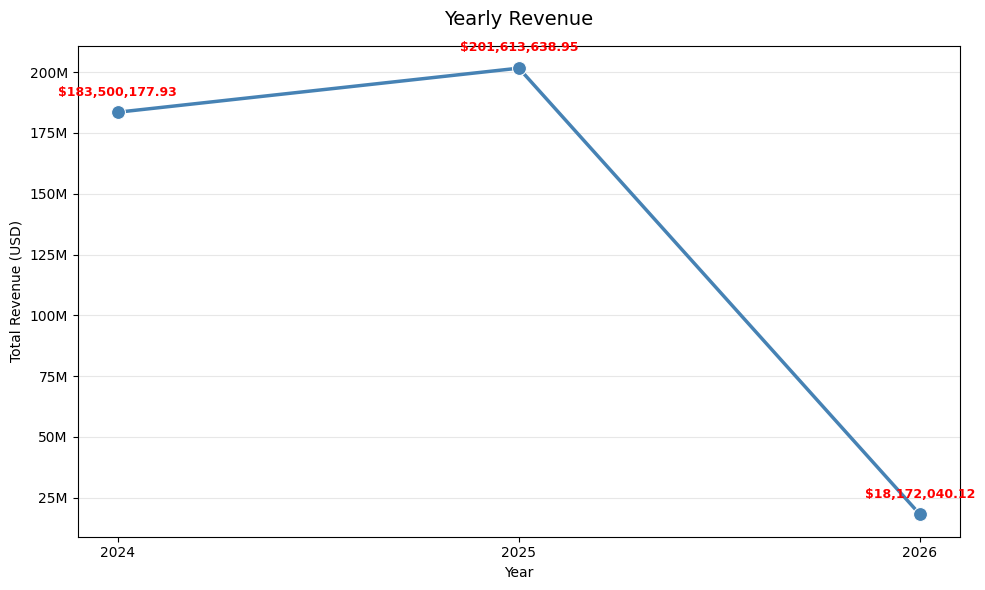

In [61]:
# 1.1.1 Yearly Revenue

yearly_revenue = (
    eda_df.groupby('order_year')['revenue_usd']
    .sum()
    .reset_index()
)

plt.figure(figsize=(10, 6))

ax = sns.lineplot(
    data=yearly_revenue,
    x='order_year',
    y='revenue_usd',
    marker='o',
    markersize=10,
    linewidth=2.5,
    color='steelblue',
)

# Add value labels on each marker
for x, y in zip(yearly_revenue['order_year'], yearly_revenue['revenue_usd']):
    ax.annotate(
        f'${y:,}',              
        (x, y),
        textcoords='offset points',
        xytext=(0, 12),
        ha='center',
        fontsize=9,
        fontweight='bold',
        color='red'
    )

plt.title('Yearly Revenue', fontsize=14, pad=15)
plt.xlabel('Year')
plt.ylabel('Total Revenue (USD)')
plt.xticks(yearly_revenue['order_year'])
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

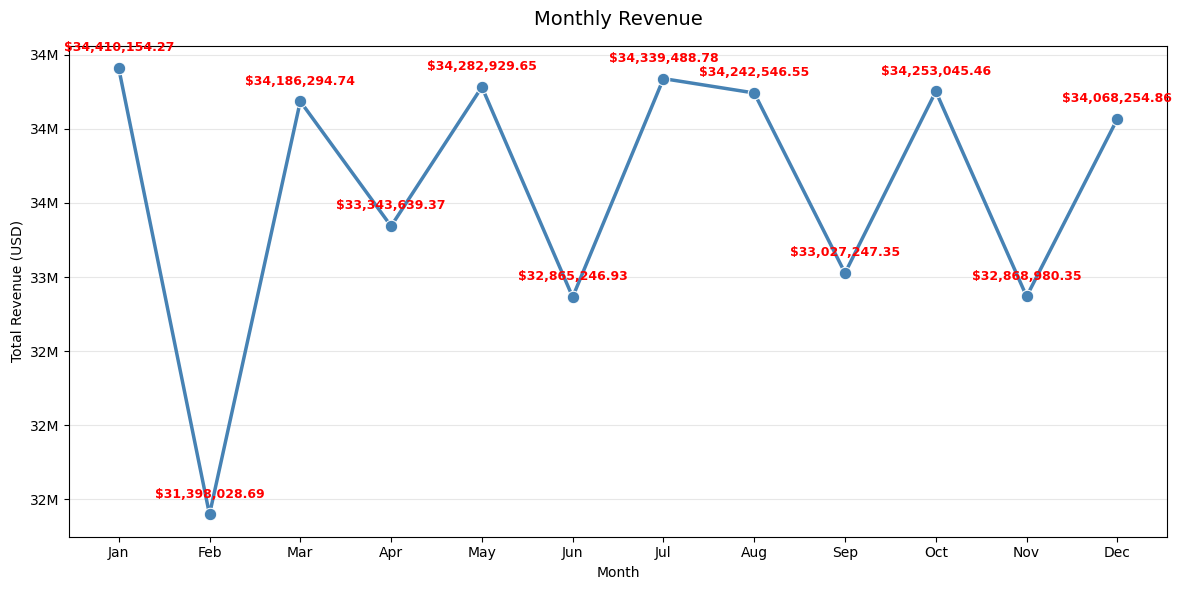

In [62]:
# 1.1.2 Monthly Revenue

month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
month_map = {i+1: m for i, m in enumerate(month_order)}

eda_df['order_month'] = eda_df['order_month'].map(month_map)

monthly_revenue = (
    eda_df.groupby('order_month')['revenue_usd']
    .sum()
    .reindex(month_order)
    .reset_index()
)

plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=monthly_revenue,
    x='order_month',
    y='revenue_usd',
    marker='o',
    markersize=9,
    linewidth=2.5,
    color='steelblue'
)

for x, y in zip(monthly_revenue['order_month'], monthly_revenue['revenue_usd']):
    ax.annotate(
        f'${y:,}',
        (x, y),
        textcoords='offset points',
        xytext=(0, 12),
        ha='center',
        fontsize=9,
        fontweight='bold',
        color='red'
    )

plt.title('Monthly Revenue', fontsize=14, pad=15)
plt.xlabel('Month')
plt.ylabel('Total Revenue (USD)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

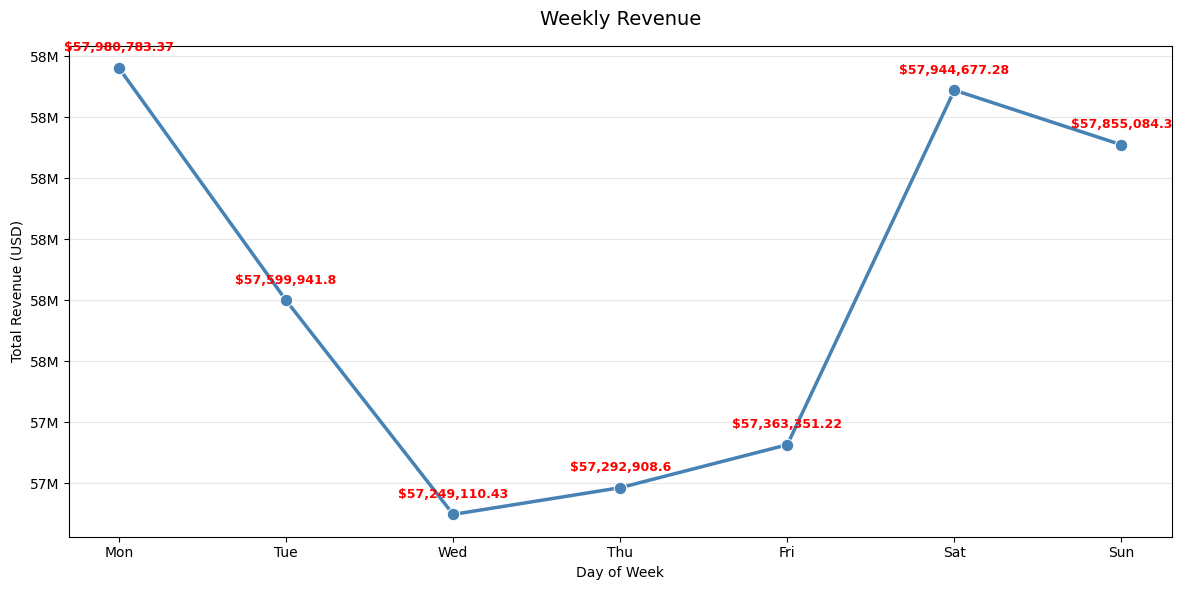

In [63]:
# 1.1.3 Day of Week Revenue

day_of_week_revenue = (
    eda_df.groupby('order_day_of_week')['revenue_usd']
    .sum()
    .reindex(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
    .reset_index()
)

plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=day_of_week_revenue,
    x='order_day_of_week',
    y='revenue_usd',
    marker='o',
    markersize=9,
    linewidth=2.5,
    color='steelblue',
)

for x, y in zip(day_of_week_revenue['order_day_of_week'], day_of_week_revenue['revenue_usd']):
    ax.annotate(
        f'${y:,}',
        (x, y),
        textcoords='offset points',
        xytext=(0, 12),
        ha='center',
        fontsize=9,
        fontweight='bold',
        color='red'
    )

plt.title('Weekly Revenue', fontsize=14, pad=15)
plt.xlabel('Day of Week')
plt.ylabel('Total Revenue (USD)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

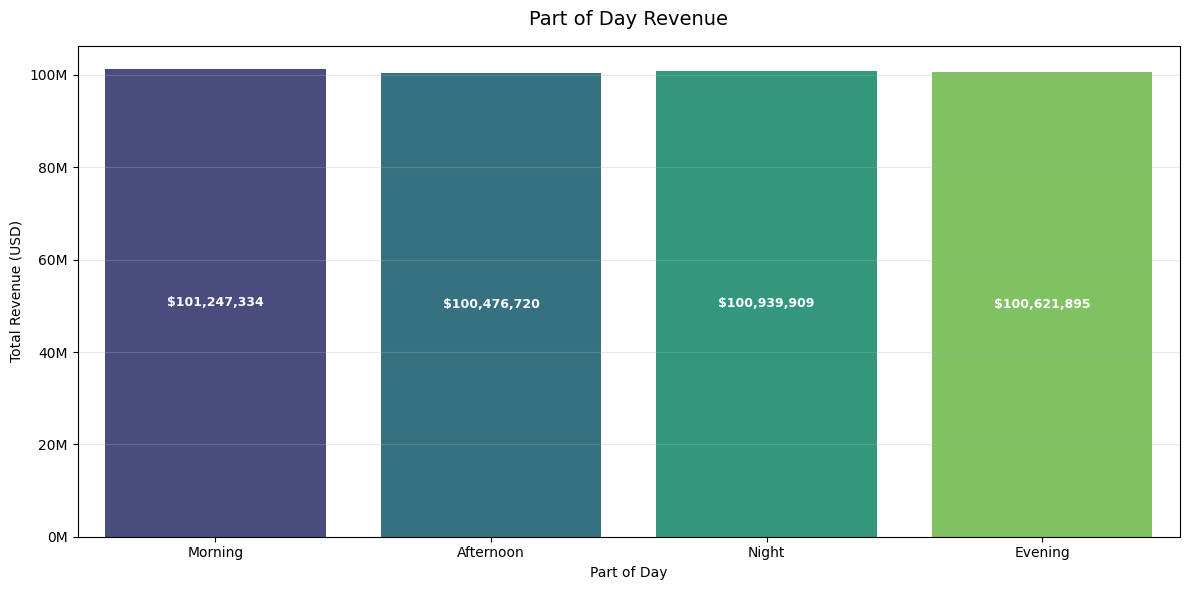

In [ ]:
# 1.1.4 Part of Day Revenue

part_day_revenue = (
    eda_df.groupby('part_day')['revenue_usd']
    .sum()
    .reindex(['Morning', 'Afternoon', 'Night', 'Evening'])
    .reset_index()
)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=part_day_revenue,
    x='part_day',
    y='revenue_usd',
    palette='viridis',
    hue='part_day',
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.0f}' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=9,
        fontweight='bold'
    )

plt.title('Part of Day Revenue', fontsize=14, pad=15)
plt.xlabel('Part of Day')
plt.ylabel('Total Revenue (USD)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

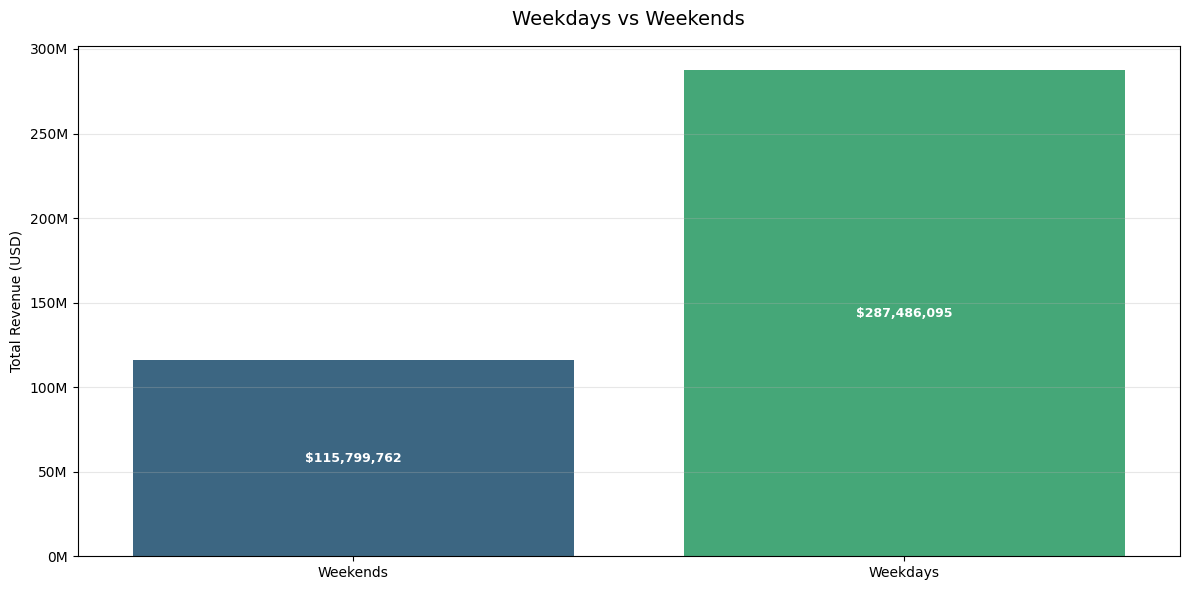

In [75]:
# 1.1.5 Weekend vs Weekedays

is_weekend_revenue = (
    eda_df.groupby('is_weekend')['revenue_usd']
    .sum()
    .reindex(['Yes', 'No'])
    .reset_index()
)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=is_weekend_revenue,
    x='is_weekend',
    y='revenue_usd',
    palette='viridis',
    hue='is_weekend',
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.0f}' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=9,
        fontweight='bold'
    )

plt.title('Weekdays vs Weekends', fontsize=14, pad=15)
plt.xlabel('')
plt.xticks([0, 1], ['Weekends', 'Weekdays'])
plt.ylabel('Total Revenue (USD)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 1.2 Revenue by Category and Sub-Category

## 1.3 Revenue by Country

## 1.4 Revenue by Order Value Segment

## 1.5 Top 10 Customers with Highest Revenue

## 1.6 Gross Revenue (Without discount) vs Revenue (With discount applied)